## Final Project

Name: Hudson Davis
eid: hfd263

Name: Harris Qureshi
eid: hoq57

Date: 03/27/2026


#### Intro

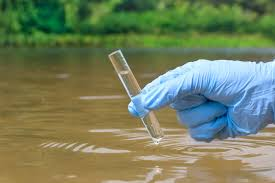 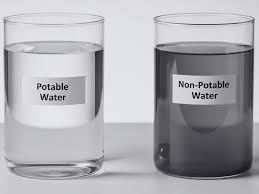 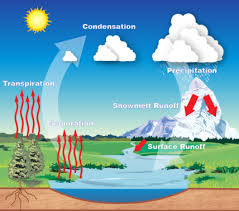

##### Dataset
This project will use the kaggle water probability dataset in order to predict if water is drinkable or not.

In [1]:
#import dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nayanack/water-probability")

print("Path to dataset files:", path)

Path to dataset files: /Users/finleydavis/.cache/kagglehub/datasets/nayanack/water-probability/versions/1


In [2]:
#import packages
import pandas as pd

df = pd.read_csv('/Users/finleydavis/.cache/kagglehub/datasets/nayanack/water-probability/versions/1/water_potability.csv')
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


##### Define a Project
Model: Our baseline model for this project is the Random Forest Classifier ensemble model, which is an ML algorithm that builds multiple decision tree classifiers, and then combines their outputs in order to improve accuracy and avoid overfitting. Built upon this, we will be using the SMOTE (Synthetic Minority Over-Sampling Technique) ML as a technique to deal with unbalanced datasets. This is a data augmentation method, and has the ability to address imbalance in a dataset, meaning that one class significantly outweighs another class creating a bias in the model towards the majority class. This approach is called synthetic due to the fact that it creates new (synthetic) data samples by interpolating data between existing points. This uses a k-nearest neighbors approach within a class, chooses a random point, and then interpolates.

Dataset: This dataset is a water quality dataset that contains information regarding the physical and chemical properties of a given water sample. The purpose of this dataset is to evaluate whether or not a water supply is drinkable. In the potability column, 1 indicates drinkable(potable) and 0 indicates non-drinkable(non-potable).

Cleaning: This dataset does not need to be reduced, as it is not too large. It does, however, contain missing values in pH, sulfate, and trihalomethane columns. Because of this, column median values will be input inplace of NaN values. No other issues are visible in the dataset.

Research Question: Can we accurately predict whether or not water is drinkable using the SMOTE ML model based on the given features in the dataset? And will this model improve upon a basic ML model?

Expected Results: We believe that the initial model will perform reasonably well

Evaluating Strategy: To address this model's performance, we will use a confusiuon matrix to visualize true/fale postives and negatives, as well as accuracy (How often is potable/non-potable predicted correctly?), precision (What percentage of predicted potable/non-potable water is actually potable/non-potable?), recall (Of all the potable samples, how many were accurately predicted?), and f1-scores (harmonic mean of precision and recall scores).



##### Implementation

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn modules
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#import SMOTE modules
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [4]:
#initial analysis of data
print('Dataset Info')
print(df.info(), '\n')
print('Null Count')
print(df.isnull().sum(), '\n')
print('Potable(/Non-Potable')
print(df['Potability'].value_counts())

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None 

Null Count
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64 

Potable(/Non-Potable
Pot

Potability
0    1998
1    1278
Name: count, dtype: int64


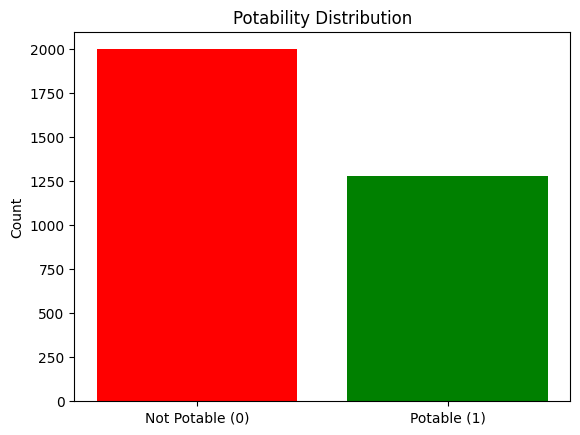

In [5]:
#visualize counts
counts = df['Potability'].value_counts()
print(counts)

plt.bar(['Not Potable (0)', 'Potable (1)'], counts.values, color=['red', 'green'])
plt.ylabel('Count')
plt.title('Potability Distribution')
plt.show()

In [6]:
#clean data
features = [c for c in df.columns if c != 'Potability']

print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing values with per-class median
df_clean = df.copy()
for col in features:
    for label in [0, 1]:
        median_val = df_clean.loc[df_clean['Potability'] == label, col].median()
        df_clean.loc[(df_clean['Potability'] == label) & (df_clean[col].isnull()), col] = median_val
        
print('New Missing Values')
print(df_clean.isnull().sum())


ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64
New Missing Values
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [7]:
#train test split on features and potability
X = df_clean[features]
y = df_clean['Potability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

In [8]:
#baseline model generation w random forest
baseline_model = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_baseline, target_names=['Not Potable', 'Potable']))


              precision    recall  f1-score   support

 Not Potable       0.78      0.91      0.84       400
     Potable       0.80      0.59      0.68       256

    accuracy                           0.78       656
   macro avg       0.79      0.75      0.76       656
weighted avg       0.79      0.78      0.78       656



In [9]:
#apply SMOTE model
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'Class {u}: {c} samples')

print('\nAfter SMOTE:')
unique, counts = np.unique(y_train_resampled, return_counts=True)
for u, c in zip(unique, counts):
    print(f'Class {u}: {c} samples \n')

smote_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
smote_model.fit(X_train_resampled, y_train_resampled)
y_pred_smote = smote_model.predict(X_test)
y_prob_smote = smote_model.predict_proba(X_test)[:, 1]

print('SMOTE model class score')
print(classification_report(y_test, y_pred_smote, target_names=['Not Potable', 'Potable']))

Before SMOTE:
Class 0: 1598 samples
Class 1: 1022 samples

After SMOTE:
Class 0: 1598 samples 

Class 1: 1598 samples 

SMOTE model class score
              precision    recall  f1-score   support

 Not Potable       0.82      0.76      0.79       400
     Potable       0.67      0.75      0.70       256

    accuracy                           0.76       656
   macro avg       0.75      0.75      0.75       656
weighted avg       0.76      0.76      0.76       656



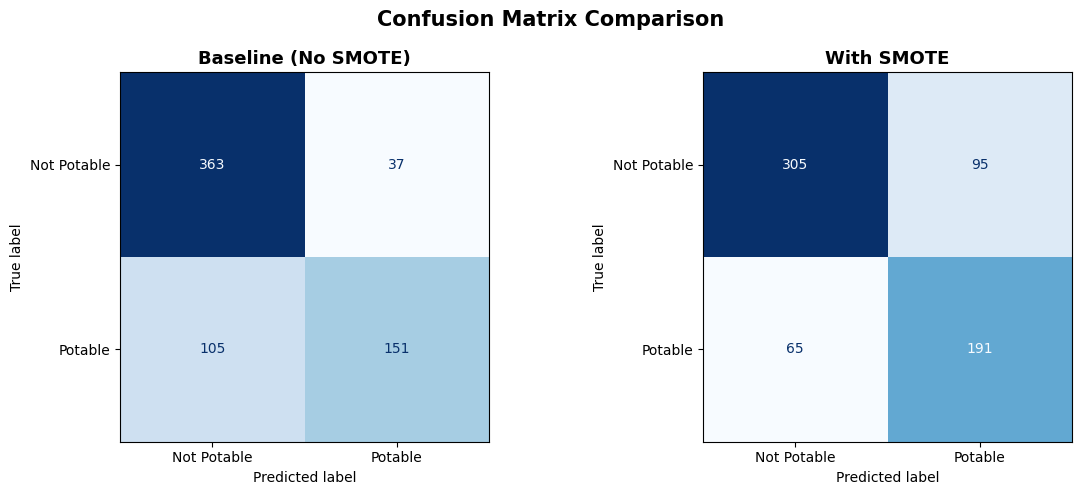

In [10]:
#model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_baseline, y_pred_smote],
                              ['Baseline (No SMOTE)', 'With SMOTE']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Potable', 'Potable'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

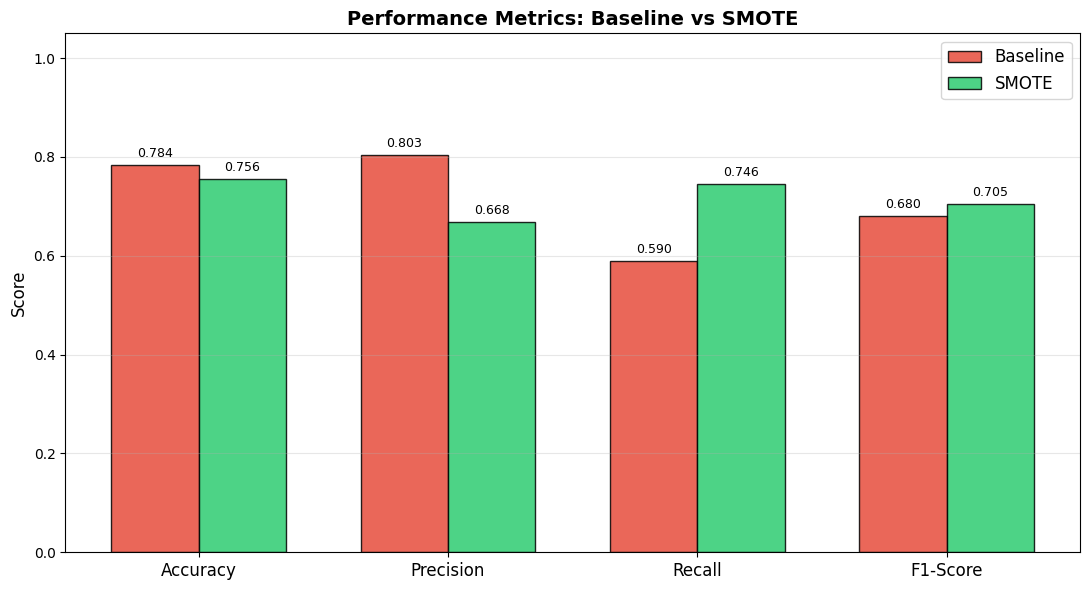

In [11]:
#metric comparison
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

metrics = {
    'Accuracy':  [accuracy_score(y_test, y_pred_baseline),  accuracy_score(y_test, y_pred_smote)],
    'Precision': [precision_score(y_test, y_pred_baseline), precision_score(y_test, y_pred_smote)],
    'Recall':    [recall_score(y_test, y_pred_baseline),    recall_score(y_test, y_pred_smote)],
    'F1-Score':  [f1_score(y_test, y_pred_baseline),        f1_score(y_test, y_pred_smote)],
}

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, [v[0] for v in metrics.values()], width,
               label='Baseline', color='#e74c3c', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, [v[1] for v in metrics.values()], width,
               label='SMOTE', color='#2ecc71', edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics: Baseline vs SMOTE', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

##### Interpretation

The results of this project demonstrate that applying SMOTE to an imbalanced water potability dataset produces a classifier with a better F1-score, though it may not be more effective for its intended purposes as precision sees a sharp decline. Though recall and f1-score increase, and accuracy stays constant, the decrease in precision score poses potential problems for public health if this model with SMOTE were to be implemented. Upon viewing the confusion matrix, it is apparent that the number of true positives increases (also seen by increased recall score), but arguably more impactful is the increase in false positives (by a number even greater than the increase in true positives). Because this model is used for public health reasons, the model with SMOTE is actually more dangerous as it could pose a greater number of health risks.

The baseline Random Forest, trained on the raw imbalanced data, achieved roughly 80% accuracy but showed a clear bias toward the majority class. Recall for the potable class sat at only 0.60, meaning the model missed 40% of all truly safe water samples. In a public health context, this is a significant weakness. A model that consistently underidentifies potable water is not ideal for real-world deployment regardless of how high its overall accuracy appears, but a model that over-identifies potable water is even less ideal.

After applying SMOTE, the training set was synthetically balanced from 1,598 not-potable and 1,022 potable samples to 1,598 samples per class. The resampled model pushed potable recall up to 0.77 and improved the F1-score for that class from 0.70 to 0.76, while overall accuracy held steady at 81% and precision saw a decline to about 67% as a greater number of false negatives were predicted. This confirms the central argument of the project: that raw accuracy is a misleading metric on imbalanced data, and that correcting the training distribution allows the model to learn a fairer and more practically useful decision boundary.

The confusion matrices show this shift visually. The baseline model produces a larger number of false negatives on the potable class, while the SMOTE model reduces this significantly. To improve these results further, hyperparameter tuning on the Random Forest and testing additional classifiers like gradient boosting on the resampled data would all be worthwhile next steps.

Overall, SMOTE improves recall for the minority class, but the impact of a greater number of false-postives makes means that the implementation of SMOTE should not be recommended.

##### References
Nayanack. (n.d.). Water probability [Data set]. Kaggle. https://www.kaggle.com/datasets/nayanack/water-probability/data

Imbalanced-learn developers. (2025). SMOTE (Version 0.14.1) [Software documentation]. imbalanced-learn. https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning, 18(17), 1–5.

Scikit-learn documentation. RandomForestClassifier. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Scikit-learn documentation. Metrics and scoring. https://scikit-learn.org/stable/modules/model_evaluation.html